# 12: Modeling the Fuel-Cost Relationship, and a Summary Dashboard

**Business question**: Notebook 2 showed CASK rising alongside fuel price across four quarters. This notebook formalizes that relationship with a small regression model, and closes with a one-page summary view of the whole project's key numbers.

**Honest framing up front**: this project has only **four** quarters of comparable operating-statistics data (1Q25 proforma, 1Q26, 2Q25 proforma, 2Q26). A regression on four points cannot be a reliable predictive tool, and is not presented as one here. It is shown as a formal, quantified version of the visual relationship already established, with the small-sample caveat stated plainly rather than hidden behind a high R² number.

## A simple linear model

In [1]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from IPython.display import Image

df = pd.read_csv('../data/processed/operating_stats.csv')
X = df[['fuel_price']].values
y = df['cask'].values

model = LinearRegression()
model.fit(X, y)
r2 = model.score(X, y)

print(f"CASK = {model.intercept_:.2f} + {model.coef_[0]:.4f} x fuel_price")
print(f"R-squared: {r2:.2f} (on n=4 observations, not statistically meaningful on its own)")
print(f"Implied: each USD10/barrel increase in fuel price is associated with roughly {model.coef_[0]*10:.2f} sen higher CASK, in this small sample")
df[['quarter','fuel_price','cask']]

CASK = 14.33 + 0.0457 x fuel_price
R-squared: 0.94 (on n=4 observations, not statistically meaningful on its own)
Implied: each USD10/barrel increase in fuel price is associated with roughly 0.46 sen higher CASK, in this small sample


,quarter,fuel_price,cask
0,1Q2025 (proforma),101,19.56
1,1Q2026,110,18.87
2,2Q2025 (proforma),95,18.48
3,2Q2026,183,22.72


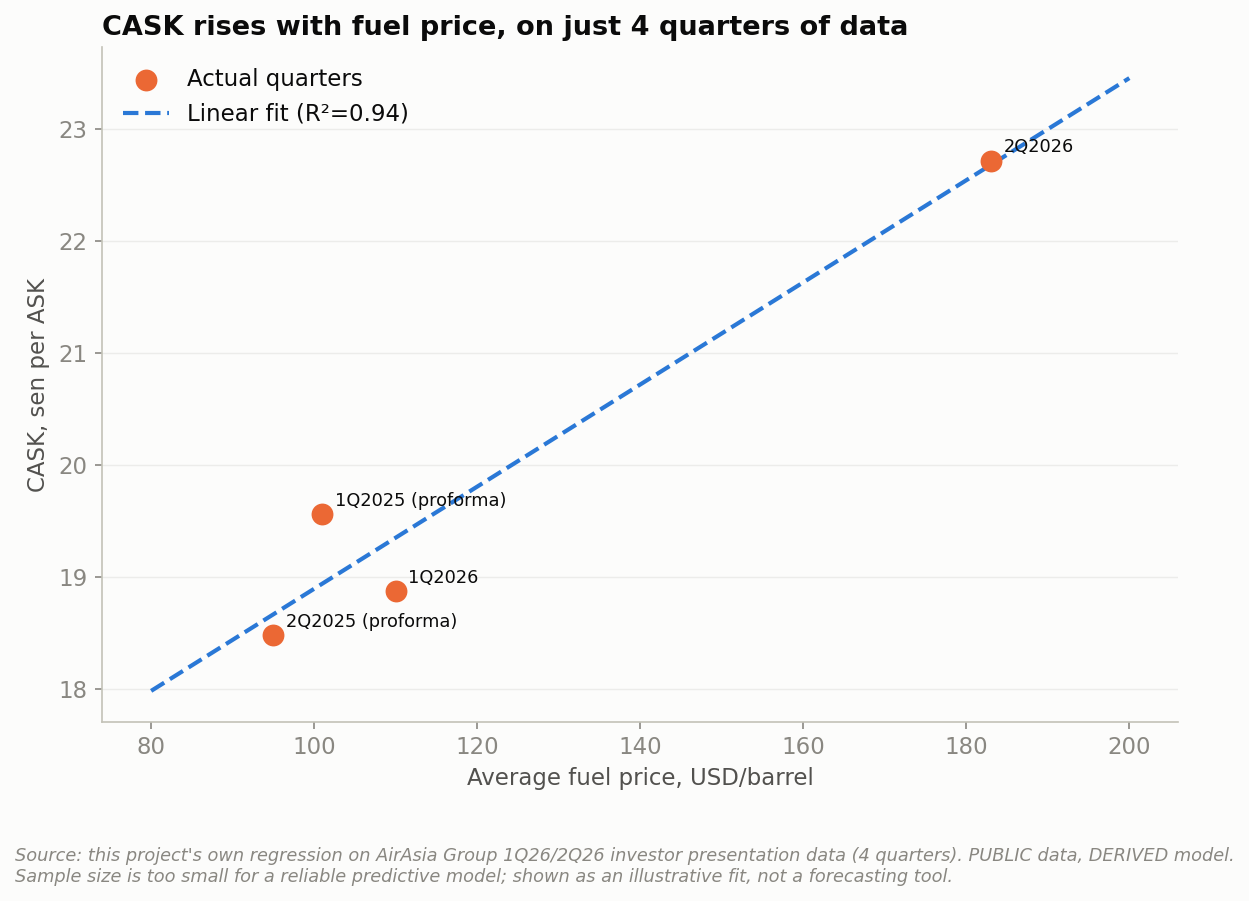

In [2]:
Image(filename='../outputs/figures/12_fuel_cask_regression.png')

The fitted line implies each USD10/barrel increase in fuel price associates with roughly 0.46 sen of additional CASK in this sample. **This is illustrative, not predictive**: with only four points and one predictor, the high R² mostly reflects that fuel price genuinely moved a lot across these four quarters (95 to 183 USD/barrel), not that the model would hold reliably out of sample. A defensible version of this model, with confidence intervals and out-of-sample validation, would need at minimum 15-20 quarters of consistent operating data, which does not exist yet for the consolidated AirAsia Group given it only formed in January 2026.

## A one-page summary dashboard

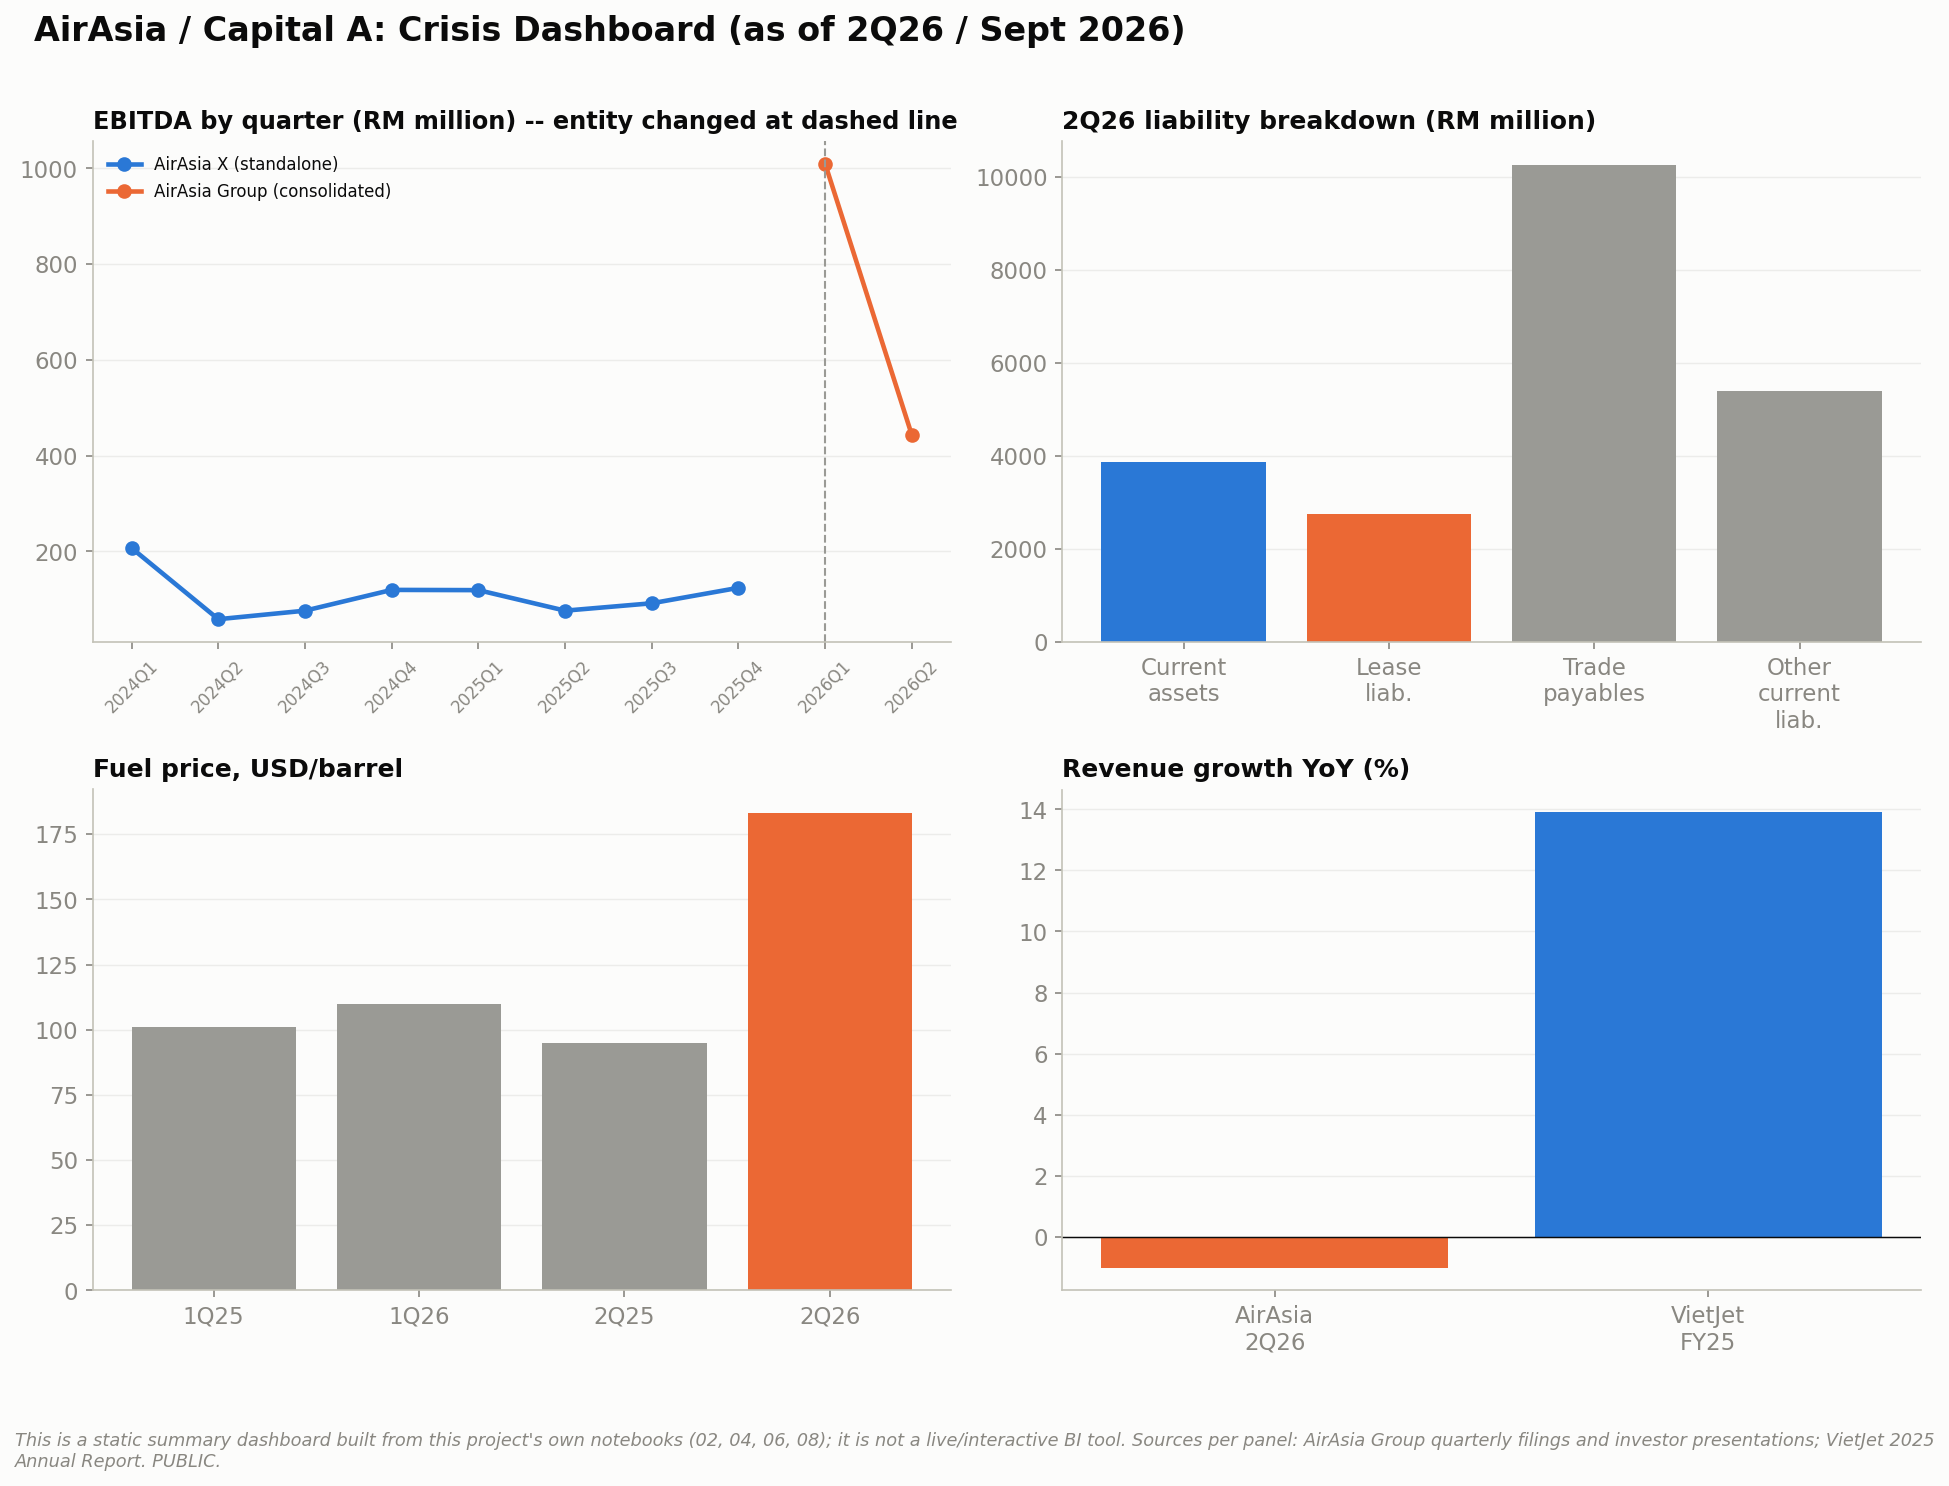

In [3]:
Image(filename='../outputs/figures/13_executive_dashboard.png')

This is a **static** summary image built from this project's own SQL database and notebooks, not a live or interactive business-intelligence tool (no Tableau Public or Power BI service was used to publish this project). The underlying SQLite database (`data/processed/airasia.db`) is structured so that a reader with Tableau, Power BI, or any BI tool that connects to SQLite could build a genuinely interactive version directly from it; that step was intentionally left as a possible extension rather than claimed as delivered.

## Explain It Simply

This notebook does two things. First, it puts a number on the relationship between fuel prices and AirAsia's costs that earlier notebooks showed visually: roughly, every $10 more per barrel of fuel adds about half a sen to the cost of flying each seat one kilometre. That number comes from only four data points, so it should be read as "this is the pattern so far," not "this is a proven formula." Second, it puts the project's biggest numbers, EBITDA, the liability breakdown, fuel prices, and the competitor comparison, onto one summary page. That page is a picture, not a live tool you can click into, but it's built from the same real database everything else in this project uses, so a real interactive dashboard could be built from it later.

## Glossary

- **Linear regression**: a statistical method fitting a straight-line relationship between one variable (here, fuel price) and another (CASK).
- **R-squared**: a measure of how much of the variation in one variable is statistically explained by another; unreliable with very few data points.
- **Static dashboard**: a fixed image summarizing key data, as opposed to an interactive tool a viewer can filter, click, or drill into.

## Why Is This Happening?

**Why not just build the interactive dashboard, since the data is already in a database?** Publishing a genuinely live Tableau Public or Power BI dashboard requires an account on that specific platform and a manual publishing step outside this notebook environment, a real tooling boundary, not a data limitation. Being explicit about that boundary here, rather than presenting a static image as if it were interactive, follows the same disclosure standard this project has applied to every other limitation, including the small regression sample size above.

---
**Sources**: this project's own SQL database and processed data (`data/processed/airasia.db`, `operating_stats.csv`), built from AirAsia Group and VietJet primary filings cited in Notebooks 2, 4, 6, and 8. All underlying figures **PUBLIC**; the regression model and dashboard are this project's own analysis, classified **DERIVED**.